# An Exercise in Car Prices

![Used Dealer](images/kurt.jpeg)

## Introduction

The used car market is highly dynamic, with vehicle prices influenced by a wide range of factors such as mileage, age, condition, brand, and location. For dealerships, understanding what drives these price variations is critical to making informed purchasing decisions, setting competitive prices, and aligning inventory with customer demand. In this project, we analyze a large dataset of used car listings to identify the key attributes that impact vehicle pricing. By applying data analysis and machine learning techniques, the goal is to uncover actionable insights that help a used car dealership better understand consumer preferences and optimize their pricing and inventory strategy.

## Framework

<img src="images/crisp.png" width="400">

To guide this analysis, I will use the CRISP-DM (Cross-Industry Standard Process for Data Mining) framework, a widely adopted methodology for structuring data science projects. CRISP-DM provides a clear, iterative process that moves from business understanding to data understanding, data preparation, modeling, evaluation, and ultimately deployment. Using this framework ensures that the analysis stays grounded in the original business objective, which is identifying what drives used car prices, while maintaining a disciplined approach to data exploration and model development.

## Business Understanding

From a data perspective, this problem can be framed as a supervised learning regression task. The objective is to model the relationship between a vehicle’s features (e.g., mileage, age, make, model, condition, fuel type, and location) and its price, treating price as the continuous target variable.

Using the dataset, we will perform exploratory data analysis (EDA) and feature engineering to identify and prepare relevant predictors, followed by training regression models to quantify the impact of each feature on price. The final goal is to evaluate model performance and interpret feature importance to determine the key factors that drive used car pricing.

## Data Understanding

To get familiar with the dataset and identify potential data quality issues, I would start with an initial inspection by reviewing the dataset’s structure, column names, data types, and overall size.

In [849]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

import matplotlib.pyplot as plt

In [850]:
# Read in data
original_data = pd.read_csv('data/vehicles.csv')
data = original_data.copy()
print(f"Number of entries: {original_data.shape[0]}.")
original_data.sample(n=5)

Number of entries: 426880.


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
194559,7303701722,ann arbor,25990,2017.0,jaguar,xf 35t premium sedan 4d,good,NaN,other,29170.0,clean,other,SAJBD4BV2HCY34375,NaN,NaN,sedan,blue,mi
267443,7309441328,buffalo,12000,1997.0,chevrolet,3500,NaN,NaN,diesel,75000.0,clean,manual,NaN,NaN,NaN,NaN,NaN,ny
2626,7315971696,huntsville / decatur,6800,2009.0,volkswagen,beetle convertible,good,4 cylinders,gas,70308.0,rebuilt,automatic,NaN,rwd,NaN,NaN,black,al
148735,7312553514,"st louis, MO",21831,2016.0,audi,a3 e-tron,NaN,NaN,hybrid,38561.0,clean,automatic,NaN,fwd,NaN,hatchback,black,il
85328,7306644428,hartford,10995,2012.0,NaN,TOYOTA* CAMRY*,NaN,NaN,gas,117321.0,clean,automatic,4T4BF1FK5CR191919,fwd,full-size,other,grey,ct


In [851]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

I would assess feature relevance and remove columns that are unlikely to provide predictive value, such as VIN, which serves as a unique identifier but does not meaningfully contribute to determining a vehicle’s price. I would then check for missing data across all features, assessing both the amount and pattern of missingness to determine whether imputation or removal is appropriate. From there, I would examine categorical variables (such as make, model, and condition) to identify inconsistencies, rare categories, or possible data entry errors.

## Data Preparation

Remove the VIN column and the id column, as they are identitive and do not contribute to the pricing model.

In [852]:
data.drop(columns=['VIN', 'id'], inplace=True)

Some of the object columns would be better suited as category columns. Manufacturer, condition, fuel, title status, transmission, drive, size, type, paint color, and state seem to be good candididates for categories.

In [853]:
cat_cols = [
    'manufacturer', 'condition', 'fuel', 'title_status',
    'transmission', 'drive', 'size', 'type', 'paint_color',
    'state'
]

for col in cat_cols:
    if col in data.columns:
        data[col] = data[col].astype('category')

In [854]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   region        426880 non-null  object  
 1   price         426880 non-null  int64   
 2   year          425675 non-null  float64 
 3   manufacturer  409234 non-null  category
 4   model         421603 non-null  object  
 5   condition     252776 non-null  category
 6   cylinders     249202 non-null  object  
 7   fuel          423867 non-null  category
 8   odometer      422480 non-null  float64 
 9   title_status  418638 non-null  category
 10  transmission  424324 non-null  category
 11  drive         296313 non-null  category
 12  size          120519 non-null  category
 13  type          334022 non-null  category
 14  paint_color   296677 non-null  category
 15  state         426880 non-null  category
dtypes: category(10), float64(2), int64(1), object(3)
memory usage: 23.6+ MB


This leaves the columns region, model, and cylinders. For cylinders, even though it is a bit categorical, I'm going to just extract the decimal number from it and treat the column as numerical.

In [855]:
data['cylinders'] = data['cylinders'].str.extract('(\d+)')
data['cylinders'] = pd.to_numeric(data['cylinders'], errors='coerce')

The model column is tricky because it has so many unique values that it’s not very useful as a straight categorical feature. I considered building separate models for each manufacturer, but with 42 different manufacturers, that would add a lot of complexity and leave less data for each model. While that approach could capture brand-specific pricing differences, it didn’t seem worth the tradeoff. Instead, I kept manufacturer as a feature in a single model, allowing it to naturally learn those differences across brands.

In [856]:
print(f"There are {data['manufacturer'].nunique()} manufacturers.")
print(f"There are {data['model'].nunique()} models.")

There are 42 manufacturers.
There are 29649 models.


To deal with missing values and the high number of unique entries, I took a few steps to make the model feature more usable. First, I filled in missing model values with "unknown_model" so I wouldn’t lose those rows and could keep the data consistent when building new features. Then, I combined manufacturer and model into a single make_model feature, since the combination tends to be more informative for pricing than either field on its own.

In order for this to work, manufacturer must be present. Empty manufacturer cells are much more problematic for pricing and modelling. Should these be dropped or filled in with 'unknown'? 

In [857]:
print(f"There are {data['manufacturer'].isnull().sum()} entries missing manufacturer, roughly {round(data['manufacturer'].isnull().mean() * 100,2)}%.")

There are 17646 entries missing manufacturer, roughly 4.13%.


I removedRows with missing manufacturer values (4.13% of the dataset) were , as manufacturer is a key predictor of vehicle price and could not be reliably imputed without introducing noise.

In [858]:
data = data.dropna(subset=['manufacturer'])

In [859]:
data['model'] = data['model'].fillna('unknown_model')

data['make_model'] = data['manufacturer'].astype(str) + ' ' + data['model'].astype(str)
print(f"There are {data['make_model'].nunique()} make model combinations.")                                                                                  

There are 24206 make model combinations.


Because there were so many unique make_model values, I kept only the top 100 most frequent ones and grouped the rest into an "other" category. This helps preserve the most important patterns in the data while keeping the model simpler and more stable.

In [860]:
top_n = 100

top_make_models = data['make_model'].value_counts().nlargest(top_n).index

data['make_model_grouped'] = data['make_model'].where(
    data['make_model'].isin(top_make_models),
    'other'
)

data['make_model_grouped'] = data['make_model_grouped'].astype('category')

data = data.drop(columns=['model', 'make_model'], errors='ignore')

I removed the region feature due to its high cardinality and overlap with state, as it introduced unnecessary complexity without providing significant additional predictive value.

In [861]:
data = data.drop(columns=['region'], errors='ignore')

All data is now either numeric or categorical.

In [862]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409234 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   price               409234 non-null  int64   
 1   year                409228 non-null  float64 
 2   manufacturer        409234 non-null  category
 3   condition           241951 non-null  category
 4   cylinders           238614 non-null  float64 
 5   fuel                406681 non-null  category
 6   odometer            405083 non-null  float64 
 7   title_status        401485 non-null  category
 8   transmission        406947 non-null  category
 9   drive               286072 non-null  category
 10  size                115301 non-null  category
 11  type                322862 non-null  category
 12  paint_color         285082 non-null  category
 13  state               409234 non-null  category
 14  make_model_grouped  409234 non-null  category
dtypes: category(11), floa

Now to start assessing missing data.

In [863]:
missing_summary = pd.DataFrame({
    'missing_count': data.isnull().sum(),
    'missing_percent': data.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
size,293933,71.825166
cylinders,170620,41.692528
condition,167283,40.877102
paint_color,124152,30.337655
drive,123162,30.095740
type,86372,21.105773
title_status,7749,1.893538
odometer,4151,1.014334
fuel,2553,0.623848
transmission,2287,0.558849


I removed the size feature due to a high proportion of missing values (~72%), which limited its reliability and potential contribution to the model.

In [864]:
data = data.drop(columns=['size'], errors='ignore')

Features with moderate missingness, such as condition and cylinders (~40%), will be retained due to their relevance to vehicle pricing. I am adding an 'unknown' category to  condition. As for cylinders, since it's numeric, I'm going to add a 'missing cylinders' feature to retain that information, and then fill in the empty cylinders with a median value. This lets the model 'learn' if missing cylinders values matter

In [865]:
data['condition'] = data['condition'].cat.add_categories('unknown')
data['condition'] = data['condition'].fillna('unknown')

In [866]:
data['cylinders_missing'] = data['cylinders'].isnull().astype(int)
data['cylinders'] = data['cylinders'].fillna(data['cylinders'].median())

Paint color, drive, and type all contain useful information, so the missing cells will have an unknown category entry filled in.

In [867]:
for col in ['paint_color', 'drive', 'type']:
    data[col] = data[col].cat.add_categories('unknown')
    data[col] = data[col].fillna('unknown')

For features with minimal missingness (around 1-2%), I will use simple imputation strategies to retain as much data as possible without introducing bias. I'm filling in missing values in odometer with the median, since it is a numeric feature, and I am replacing missing values in categorical features such as title_status, fuel, and transmission with an "unknown" category. This approach keeps the dataset intact while handling missing values in a straightforward and consistent way.

In [868]:
data['odometer'] = data['odometer'].fillna(data['odometer'].median())

In [869]:
for col in ['title_status', 'fuel', 'transmission']:
    data[col] = data[col].cat.add_categories('unknown')
    data[col] = data[col].fillna('unknown')

Because only a very small number of observations were missing the year feature, I chose to remove those rows rather than impute values, as year is a key determinant of vehicle price and cannot be meaningfully estimated.

In [870]:
data = data.dropna(subset=['year'])

All missing data is now accounted for and ready for modelling.

In [871]:
missing_summary = pd.DataFrame({
    'missing_count': data.isnull().sum(),
    'missing_percent': data.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)

missing_summary

,missing_count,missing_percent
price,0,0.0
year,0,0.0
manufacturer,0,0.0
condition,0,0.0
cylinders,0,0.0
fuel,0,0.0
odometer,0,0.0
title_status,0,0.0
transmission,0,0.0
drive,0,0.0


In [872]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409228 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   price               409228 non-null  int64   
 1   year                409228 non-null  float64 
 2   manufacturer        409228 non-null  category
 3   condition           409228 non-null  category
 4   cylinders           409228 non-null  float64 
 5   fuel                409228 non-null  category
 6   odometer            409228 non-null  float64 
 7   title_status        409228 non-null  category
 8   transmission        409228 non-null  category
 9   drive               409228 non-null  category
 10  type                409228 non-null  category
 11  paint_color         409228 non-null  category
 12  state               409228 non-null  category
 13  make_model_grouped  409228 non-null  category
 14  cylinders_missing   409228 non-null  int64   
dtypes: category(10), floa

Now I want to do a sanity check on some of the data to make sure it is clean. I'm starting with the price data.

In [873]:
data['price'].describe()

count    4.092280e+05
mean     7.699672e+04
std      1.243925e+07
min      0.000000e+00
25%      5.980000e+03
50%      1.398800e+04
75%      2.600000e+04
max      3.736929e+09
Name: price, dtype: float64

At least one price entry is 0. I want to look for extreme outliers on the high end as well, anything over 1,000,000.

In [874]:
data[data['price'] < 250]

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,make_model_grouped,cylinders_missing
46,0,2011.0,jeep,excellent,6.0,gas,99615.0,clean,automatic,unknown,SUV,unknown,al,jeep compass,1
96,80,2004.0,honda,excellent,6.0,gas,94020.0,clean,automatic,unknown,unknown,unknown,al,other,0
126,0,2018.0,chevrolet,like new,6.0,gas,68472.0,clean,automatic,rwd,van,white,al,other,0
127,0,2019.0,chevrolet,like new,6.0,gas,69125.0,clean,automatic,rwd,van,white,al,other,0
128,0,2018.0,chevrolet,like new,6.0,gas,66555.0,clean,automatic,rwd,van,white,al,other,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426763,0,2009.0,toyota,excellent,4.0,hybrid,271000.0,clean,automatic,fwd,unknown,white,wy,toyota prius,0
426812,0,2006.0,toyota,excellent,4.0,gas,195000.0,clean,automatic,fwd,unknown,silver,wy,other,0
426832,0,2004.0,toyota,excellent,4.0,hybrid,239000.0,clean,automatic,fwd,unknown,blue,wy,toyota prius,0
426836,0,2018.0,ram,excellent,6.0,diesel,20492.0,clean,automatic,4wd,truck,white,wy,ram 2500,0


In [875]:
data[data['price'] > 1000000]

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,make_model_grouped,cylinders_missing
280,987654321,1960.0,chevrolet,unknown,6.0,gas,999999.0,clean,manual,unknown,unknown,unknown,al,chevrolet unknown_model,1
1838,99999999,1993.0,ford,unknown,6.0,gas,99999.0,clean,automatic,unknown,unknown,unknown,al,ford ranger,1
26075,1111111,2014.0,chevrolet,unknown,6.0,other,11.0,clean,automatic,unknown,unknown,unknown,ca,chevrolet unknown_model,1
29386,1111111111,1999.0,ford,good,8.0,diesel,149000.0,clean,automatic,rwd,pickup,white,ca,other,0
37409,1111111111,2020.0,jeep,unknown,6.0,gas,1000.0,clean,automatic,4wd,unknown,unknown,ca,other,1
37410,3009548743,2021.0,chevrolet,unknown,8.0,gas,1000.0,clean,automatic,4wd,unknown,unknown,ca,chevrolet unknown_model,0
68935,2000000,2002.0,saturn,good,4.0,gas,164290.0,clean,automatic,fwd,sedan,green,ca,other,0
91576,3024942282,2000.0,mercedes-benz,unknown,6.0,gas,100000.0,clean,automatic,unknown,unknown,unknown,de,other,1
105843,6995495,2014.0,dodge,unknown,4.0,gas,135888.0,clean,automatic,fwd,SUV,unknown,fl,dodge journey,0
122470,987654321,1960.0,chevrolet,unknown,6.0,gas,9999999.0,clean,manual,unknown,unknown,unknown,ga,chevrolet unknown_model,1


These prices, below 250 or over 1,000,000, are probably invalid data. I am filtering out listings with unrealistic prices and will track the number of removed observations to ensure the cleaning step did not excessively reduce the dataset.

In [876]:
before_count = len(data)

data = data[(data['price'] > 250) & (data['price'] < 100000)]

after_count = len(data)

print(f"Dropped rows: {before_count - after_count} ({(before_count - after_count) / before_count:.2%})")

Dropped rows: 37118 (9.07%)


Next is a sanity check on odometer readings.

In [877]:
data['odometer'].describe()

count    3.721100e+05
mean     9.728492e+04
std      1.869666e+05
min      0.000000e+00
25%      3.861900e+04
50%      8.700000e+04
75%      1.350830e+05
max      1.000000e+07
Name: odometer, dtype: float64

The maximum odometer reading in the dataset is 1,000,000 miles, which is not realistic for a typical vehicle and likely reflects data errors. To address this, I removed listings with odometer readings above 400,000 miles, which I consider a generous upper bound for valid observations.

In [878]:
data = data[data['odometer'] < 400000]

I will perform a sanity check on the years of the cars as well. Ford Model T's were produced in 1927, so it's reseasonable to say any car with a year before 1927 is invalid.

In [879]:
data['year'].describe()

count    371217.000000
mean       2011.334925
std           8.966315
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

In [880]:
data[data['year'] < 1928]

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,make_model_grouped,cylinders_missing
9653,15000,1922.0,ford,good,4.0,gas,80000.0,clean,automatic,unknown,convertible,orange,az,other,0
12581,22000,1924.0,dodge,excellent,4.0,gas,23480.0,clean,manual,rwd,sedan,black,az,other,0
12789,18500,1927.0,chevrolet,good,4.0,gas,100.0,clean,manual,fwd,coupe,green,az,other,0
13010,18500,1927.0,chevrolet,good,4.0,gas,100.0,clean,manual,fwd,coupe,green,az,other,0
16408,19500,1923.0,buick,good,4.0,gas,58.0,clean,manual,rwd,unknown,unknown,az,other,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388745,18500,1923.0,ford,like new,8.0,gas,2500.0,clean,automatic,rwd,convertible,unknown,vt,other,0
410129,15900,1927.0,chrysler,excellent,4.0,gas,5557.0,clean,manual,fwd,coupe,yellow,wa,other,0
410659,18500,1922.0,ford,excellent,8.0,gas,13000.0,clean,automatic,rwd,unknown,black,wa,ford unknown_model,0
414282,3700,1927.0,chevrolet,salvage,6.0,gas,1.0,parts only,other,rwd,pickup,grey,wv,other,1


In [881]:
before_count = len(data)

data = data[data['year'] > 1927]

after_count = len(data)

print(f"Dropped rows: {before_count - after_count} ({(before_count - after_count) / before_count:.2%})")

Dropped rows: 95 (0.03%)


I'm doing a sanity check on some of the categories as well. I'm looking for misspellings or other weird data.

In [882]:
for col in ['manufacturer', 'condition', 'fuel', 'transmission']:
    print(data[col].value_counts().head(), '\n')

manufacturer
ford         63892
chevrolet    49655
toyota       31115
honda        19573
nissan       17082
Name: count, dtype: int64 

condition
unknown      142008
good         113285
excellent     89537
like new      18869
fair           5983
Name: count, dtype: int64 

fuel
gas        313553
other       26647
diesel      22495
hybrid       4735
unknown      2164
Name: count, dtype: int64 

transmission
automatic    290269
other         58668
manual        20490
unknown        1695
Name: count, dtype: int64 



Last, I want to take a look at duplicates.

In [883]:
data.duplicated().sum()

np.int64(110027)

There are a lot of duplicate entries in the dataset, and it’s not entirely clear whether they reflect real repeated listings or just artifacts from how the data was collected. For this analysis, I’m going to assume they’re legitimate and leave them in.

## Modelling and Evaluation

To begin modelling, I'm first splitting the data into a training set and a test set. I'm setting the random state to a specific seed for reproducability.

In [884]:
# Split the input data from the target
X = data.drop(columns=['price'])
y = data['price']

# Now create the training and test data sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Next I'm going to setup my baseline model, which will be simple LinearRegression with OneHotEncoding for the categories.

In [885]:
# These are the columns to one-hot encode.
cat_cols = [
    'manufacturer', 'make_model_grouped', 'fuel',
    'transmission', 'condition', 'drive',
    'paint_color', 'title_status', 'type', 'state'
]

# Defining the numeric columns for later
num_cols = ['year', 'odometer', 'cylinders']

# Create a preprocessor to one-hot encode the categories
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Now make a simple baseline linear regression model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [886]:
# Fit the training data set
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [887]:
# Evaluate the model with the test data set
y_pred = model.predict(X_test)

# Calculate the mean sqaured error and the r-squared result
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print out the mean squared error and the r-squared result
print("MSE:", mse)
print("R-squared:", r2)

MSE: 88757159.2032212
R-squared: 0.5599919971339307


The baseline linear regression model achieved an R-squared of about 0.33, meaning it explains roughly a third of the variation in car prices. That’s a reasonable starting point, but it also shows the model is likely underfitting and missing some of the more complex relationships in the data. From here, there’s clear room for improvement through better feature engineering and more advanced modeling techniques.

In [888]:
# Create a preprocessor to one-hot encode the categories and scale the numeric columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Make a new model with Ridge regression
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

In [889]:
# Fit the training data set
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [890]:
# Evaluate the new model with the test data set
y_pred = model.predict(X_test)

# Calculate and print the mean squared error and the r-squared result
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R-squared:", r2)

MSE: 76149052.35722843
R-squared: 0.6224958893610937


After switching to Ridge regression and adding feature scaling, the model performance improved significantly, with R-squared increasing from about 0.33 to 0.49. This suggests that regularization helped the model better handle the large number of categorical features, while scaling ensured that numeric variables were appropriately balanced during training.

I wanted to improve on the earlier model, which had an R-squared of about 0.49, so I thought more about how vehicle age actually affects pricing. First I plotted out vehicle year versus price. 

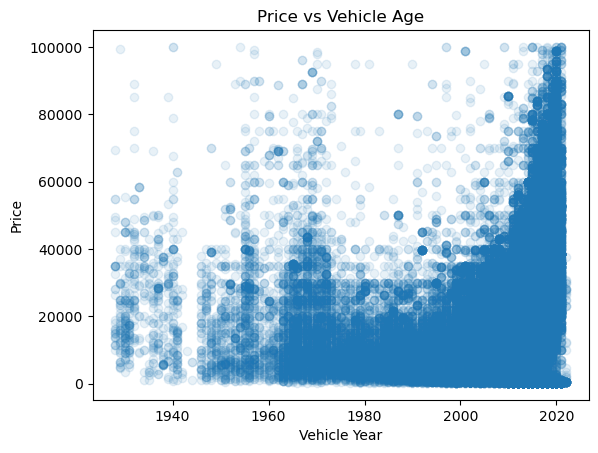

In [891]:
plt.scatter(data['year'], data['price'], alpha=0.1)
plt.xlabel('Vehicle Year')
plt.ylabel('Price')
plt.title('Price vs Vehicle Age')
plt.show()

After plotting vehicle year vesus price, I noticed that age depreciation isn’t linear. Cars tend to lose value quickly in the first few years and then level off over time. To better capture that pattern, I added a squared age term to the model. This allows the model to account for the nonlinear relationship between age and price.

In [892]:
#Calculate the age of the vehicle based on year
data['age'] = 2026 - data['year']

# Drop any invalid ages
data = data[data['age'] >= 0]

# Add a nonlinear age feature to the dataset
data['age_squared'] = data['age'] ** 2

In [893]:
# Need to recreate the training and testing data sets since we added features, and not using year anymore
X = data.drop(columns=['price', 'year'])

# New training and test sets, using same random seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Redo the preprocessor to handle age and age_squared
num_cols = ['age', 'age_squared', 'odometer', 'cylinders']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Make a new model with age and Ridge regression
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

# Fit the model
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)

# Calculate and print the mean squared error and the r-squared result
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R-squared:", r2)

MSE: 66088177.055065535
R-squared: 0.6723720423219312


Adding age and age_squared led to a significant improvement in model performance, with R-squared increasing to around 0.63. This suggests that accounting for nonlinear relationships, particularly in how age impacts price, adds meaningful predictive power to the model.

Next I took a look at the relationship of milage versus price.

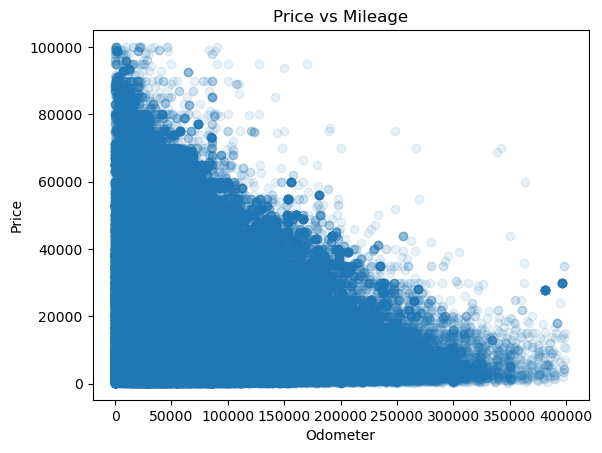

In [894]:
# Plot the milage versus the price
plt.scatter(data['odometer'], data['price'], alpha=0.1)
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.title('Price vs Mileage')
plt.show()

The plot of mileage versus price shows a clear negative relationship, where vehicles with higher mileage generally have lower prices. However, the relationship does not look perfectly linear. This suggests that while mileage is an important factor in determining price, it is not as strong a predictor as other variables, such as vehicle age, and should be considered alongside those factors.

To better capture these nonlinear patterns, I replaced the manually created 'age_squared' feature and instead used PolynomialFeatures within the model pipeline. This approach allows the model to automatically include squared terms for age, odometer, and cylinders, as well as interaction terms between them, helping to capture more complex relationships in the data.

In [895]:
# Need to redo the training data
# First drop the unneeded columns
X = data.drop(columns=['price', 'year', 'age_squared'])

# Split the new training and test sets using the same random seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_cols = ['age', 'odometer', 'cylinders']

# Numeric pipeline, which includes PolynomialFeatures
num_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Feature transformer for all columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', num_pipeline, num_cols)
    ]
)

# Make a new model with Ridge regression
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

# Fit the model
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)

# Calculate and print the mean squared error and the r-squared result
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R-squared:", r2)

MSE: 61624761.665103465
R-squared: 0.6944991418069675


To further improve the model, I tried tuning the regularization strength in Ridge regression by testing different values of alpha. Using cross-validation, I identified the value that provided the best balance between bias and variance, leading to a slightly improved and more stable model.

In [896]:
# The alpha paramemters to try out
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0]
}

# Try out the model with the different alphas
grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# Fit the grid model to the training data
grid.fit(X_train, y_train)

# Print out the best alpha and its r-squared result
print("Best alpha:", grid.best_params_)
print("Best CV R-squared:", grid.best_score_)

Best alpha: {'regressor__alpha': 1.0}
Best CV R-squared: 0.6915422362566123


The best alpha value was 1.0, which is the default, and it produced performance consistent with my earlier results. This suggests that the model is already well-balanced and not overly sensitive to the choice of alpha.

I also wanted to explore how manufacturer influences pricing. To do this, I created a chart showing the top 25 manufacturers by number of listings along with their corresponding average prices.

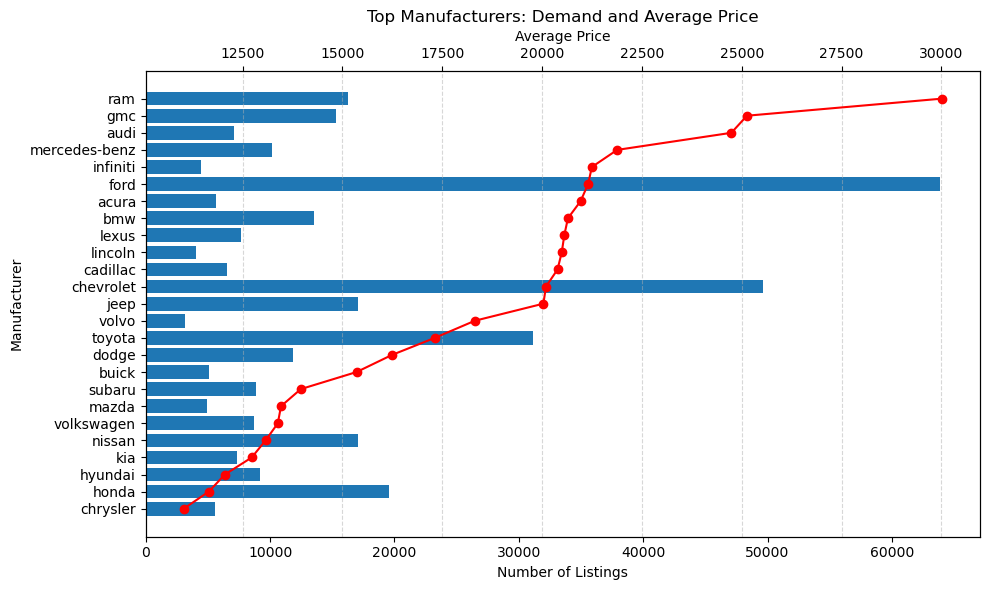

In [918]:
# Get the top 25 manufacturers by number of listings
top_makes = data['manufacturer'].value_counts().nlargest(25).index
filtered_data = data[data['manufacturer'].isin(top_makes)]

# Create a summary table with average price and listing count by manufacturer
summary = (
    filtered_data
    .groupby('manufacturer', observed=True)
    .agg(price=('price', 'mean'), count=('manufacturer', 'count'))
    .reset_index()
)

# Convert manufacturer to string so only the filtered manufacturers appear on the plot
summary['manufacturer'] = summary['manufacturer'].astype(str)

# Sort manufacturers by average price so the chart is easier to read
summary = summary.sort_values('price', ascending=True)

# Create the figure and first axis for listing count
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot number of listings as horizontal bars
ax1.barh(summary['manufacturer'], summary['count'])
ax1.set_xlabel('Number of Listings')
ax1.set_ylabel('Manufacturer')

# Create a second x-axis for average price
ax2 = ax1.twiny()

# Plot average price as a red line with markers
ax2.plot(summary['price'], summary['manufacturer'], marker='o',  color='red')

# Add grid lines to make average prices easier to compare
ax2.grid(True, axis='x', linestyle='--', alpha=0.5)
ax2.set_xlabel('Average Price')

# Add title and clean up layout
plt.title('Top Manufacturers: Demand and Average Price')
plt.tight_layout()
plt.show()

Finally, I wanted to examine the residuals to better understand where the model may be missing patterns. The residual plot is shown below.

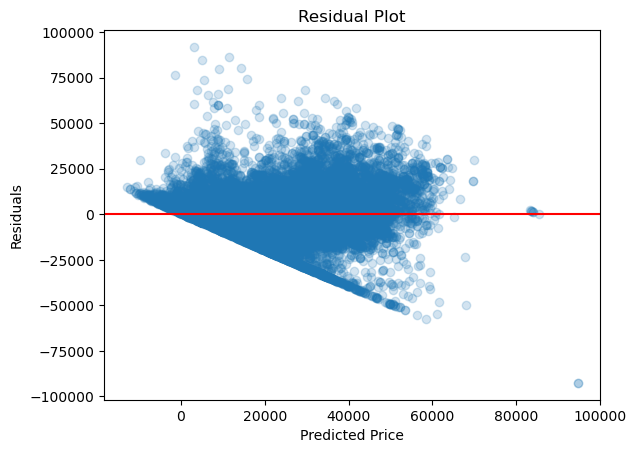

In [897]:
# Calculate the residuals
residuals = y_test - y_pred

# Plot the residuals versus the predicitions
plt.scatter(y_pred, residuals, alpha=0.2)
plt.axhline(0, color='red')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

A review of the residual plot shows that the errors are not perfectly randomly distributed. This suggests the presence of heteroscedasticity (the fan shaped pattern), which is common in pricing data where higher-value vehicles tend to have larger prediction errors. Despite this, the model still provides a strong overall fit and captures the majority of key pricing trends.

## Deployment

### Overview

The goal of this analysis was to identify the key factors that influence used car prices and provide actionable insights to help optimize inventory decisions. Using a dataset of over 400,000 used car listings, I built and refined a predictive model to better understand what drives pricing in the market.

### Key Findings

1. Vehicle age is the most important factor.
   Newer cars command higher prices. Age depreciation is nonlinear, and the price drops quickly in the first few years, and then starts to level off as the car becomes older.
2. Milage is an important factor.
   Higher milage is associated with lower prices. However, mileage alone does not explain price as strongly as age.
   


### Model Performance
- Final model: Ridge Regression with polynomial features
- R-squared ≈ 0.69, meaning the model explains about 69% of the variation in vehicle prices
- This is a significant improvement over the initial baseline (~33%)

### Recommendations

#### Inventory Strategy
- Prioritize newer vehicles, especially within the first few years
- Focus on high-demand manufacturers and models
- Balance age and mileage rather than optimizing for just one

#### Pricing Strategy
- Account for rapid early depreciation when pricing vehicles
- Use condition and features to justify price differences
- Avoid overly simplistic pricing rules—pricing should reflect multiple interacting factors

### Next Steps

While the current model performs well, there is room for further refinement:
- Test additional features (e.g., more detailed vehicle attributes)
- Explore alternative modeling approaches such as tree-based models
- Continuously retrain the model as new data becomes available

Ensure accurate and consistent capture of key fields:
- Year (age)
- Odometer
- Manufacturer and model

Reduce missing or placeholder values (e.g., price = 0), which negatively impact analysis


### Final Thoughts

This analysis shows that used car pricing is driven by a combination of vehicle age, brand, mileage, and condition, with important nonlinear relationships between these factors. By focusing on these key drivers, dealerships can make more informed decisions about which vehicles to acquire and how to price them competitively.

The final model provides a strong, data-driven foundation for improving both inventory selection and pricing strategy.